<a href="https://colab.research.google.com/github/isabella-almeida-fernandes/bank-churn-prediction/blob/main/notebooks/bank_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória de dados e comparativa de modelos
 - Conjunto de dados: `churn` (Taxa de cancelamento/rotatividade de clientes de um banco)
 - Cientista de dados:
   - Isabella Almeida (isabella4lmeidafernandes@gmail.com)
---

## Preparação para Análise Exploratória
 - Carregamento de bibliotecas
 - Configuração de estilo dos gráficos
 - Leitura do conjunto de dados

In [32]:
import itertools
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import Markdown
import math

# Tema global dos gráficos: Fundo branco, grade ativada, paleta de cores amigável a pessoas com daltonismo
sns.set_theme(style="whitegrid", palette="colorblind")

In [33]:
# @title Leitura do conjunto de dados

# URL direta para o arquivo raw repositório
url = "https://raw.githubusercontent.com/isabella-almeida-fernandes/bank-churn-prediction/main/data/Churn_Modelling.csv"

# Carregamento dos dados
df = pd.read_csv(url)

In [34]:
# @title Informações iniciais
display(Markdown("### Primeiras linhas"))
display(df.head())

display(Markdown("### Ultimas linhas"))
display(df.tail())

display(Markdown("### Informação das variáveis"))
df.info()

display(Markdown("### Quantidade de valores únicos"))
df.nunique()

### Primeiras linhas

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Ultimas linhas

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


### Informação das variáveis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Quantidade de valores únicos

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


---
A partir das informações iniciais, podemos dizer que:
 - O conjunto de dados tem 10.000 unidades amostrais com 14 variáveis
 - Classificação das variáveis:
    - Quantitativa contínua: `CreditScore`, `Balance`, `EstimatedSalary`
    - Quantitativa discreta: `RowNumber`, `Age`, `Tenure`, `NumOfProducts`
    - Qualitativa nominal: `CustomerId`, `Surname`, `Geography`, `Gender`, `HasCrCard`, `IsActiveMember`, `Exited`
---

In [35]:
from typing import AsyncGenerator
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "RowNumber",
        "descricao": "O número sequencial atribuído a cada linha no conjunto de dados.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "CustomerId",
        "descricao": "Um identificador único para cada cliente.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Surname",
        "descricao": "O sobrenome do cliente.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "CreditScore",
        "descricao": "A pontuação de crédito do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Geography",
        "descricao": "A localização geográfica do cliente (país).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Gender",
        "descricao": "O gênero do cliente (feminino, masculino etc.)",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Age",
        "descricao": "A idade do cliente.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Tenure",
        "descricao": "O número de anos que o cliente é correntista do banco.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Balance",
        "descricao": "O saldo da conta do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "NumOfProducts",
        "descricao": "O número de produtos bancários que o cliente possui.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "HasCrCard",
        "descricao": "Indica se o cliente possui um cartão de crédito (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "IsActiveMember",
        "descricao": "Indica se o cliente é um membro ativo (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "EstimatedSalary",
        "descricao": "O salário estimado do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Exited",
        "descricao": "Indica se o cliente saiu do banco (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    }
    ])
df_dict

,variavel,descricao,tipo,subtipo
0,RowNumber,O número sequencial atribuído a cada linha no ...,quantitativa,discreta
1,CustomerId,Um identificador único para cada cliente.,qualitativa,nominal
2,Surname,O sobrenome do cliente.,qualitativa,nominal
3,CreditScore,A pontuação de crédito do cliente.,quantitativa,contínua
4,Geography,A localização geográfica do cliente (país).,qualitativa,nominal
5,Gender,"O gênero do cliente (feminino, masculino etc.)",qualitativa,nominal
6,Age,A idade do cliente.,quantitativa,discreta
7,Tenure,O número de anos que o cliente é correntista d...,quantitativa,discreta
8,Balance,O saldo da conta do cliente.,quantitativa,contínua
9,NumOfProducts,O número de produtos bancários que o cliente p...,quantitativa,discreta


# Análise Univariada

In [36]:
# @title Resumo estatístico

display(Markdown("### Variáveis qualitativas"))
cols_qualitativas = ['Surname', 'Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']
print(df[cols_qualitativas].astype('object').describe())

display(Markdown("### Variáveis quantitativas"))
cols_quantitativas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
print(df[cols_quantitativas].describe())

### Variáveis qualitativas

       Surname Geography Gender  HasCrCard  IsActiveMember  Exited
count    10000     10000  10000      10000           10000   10000
unique    2932         3      2          2               2       2
top      Smith    France   Male          1               1       0
freq        32      5014   5457       7055            5151    7963


### Variáveis quantitativas

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

       EstimatedSalary  
count     10000.000000  
mean     100090.239881  
std       57510.492818  
min          11.580000  
25%       51002.110000  
50%      100193.915000  
75%      149388.247500  
max      199992.480000  


---

- A maioria dos clientes são `homens`
- A média de idade dos clientes é  de `38,9 anos`
- A maior parte dos clientes são da `França`
- A grande maioria dos clientes `possui cartão de crédito`
- Pelo menos `metade dos clientes tem a conta ativa`, ou seja, realiza movimentações
- Apenas `20% dos clientes cancelou` o serviço com o banco

---

# Distribuição de Variáveis

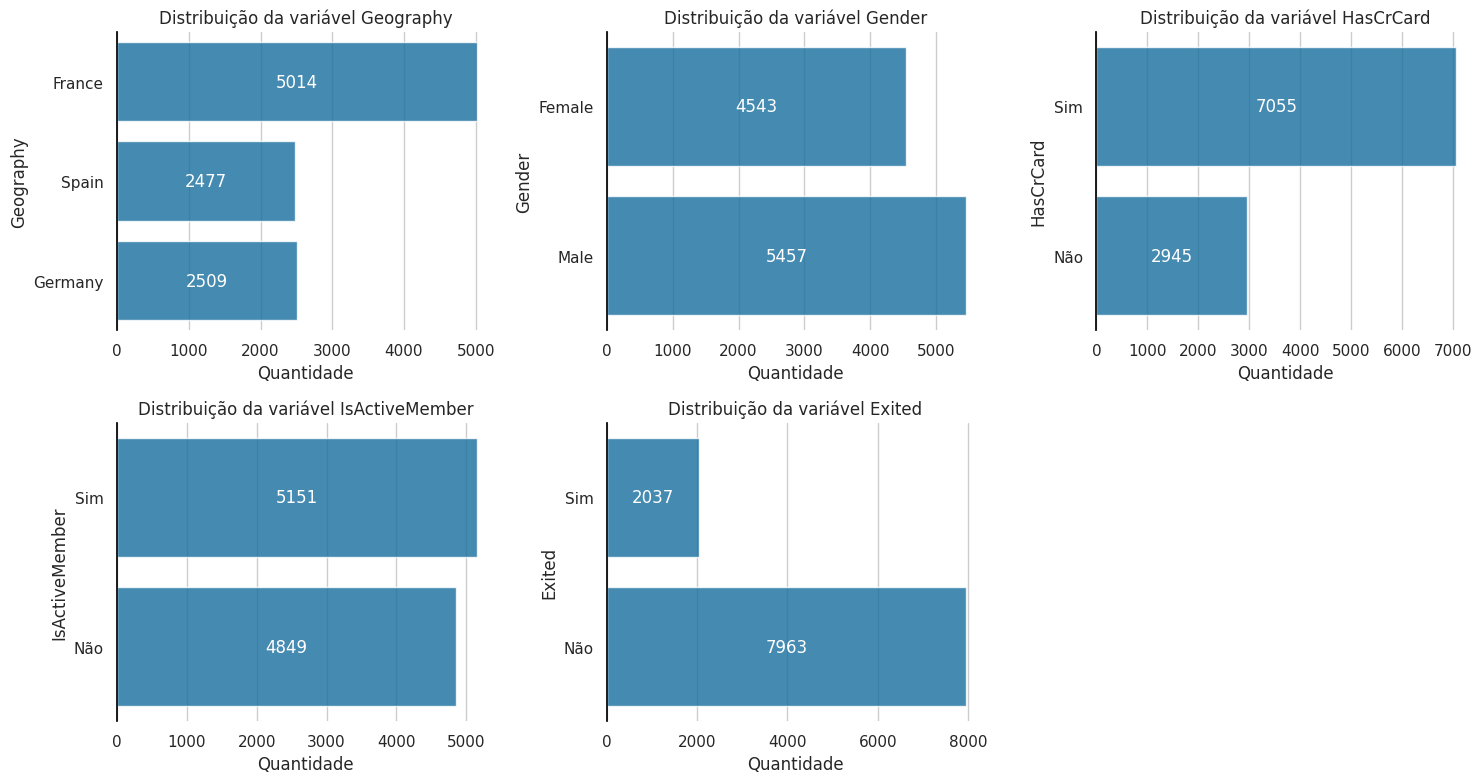

In [37]:
# @title Variáveis qualitativas
variaveis_qualitativas = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']

fig, axes = plt.subplots(figsize=(15, 8), ncols=3, nrows=2)
axes = axes.flatten()

# Dicionário de mapeamento para variáveis binárias (0 e 1)
mapa_legenda = {0: 'Não', 1: 'Sim'}

# Criar cópia temporária da coluna para o gráfico

for i, variavel in enumerate(variaveis_qualitativas):
    if variavel in ['HasCrCard', 'IsActiveMember', 'Exited']:
        dados_para_plotar = df[variavel].map(mapa_legenda)
    else:
        dados_para_plotar = df[variavel]

    # Criar a figura
    ax = sns.countplot(df, y=dados_para_plotar, ax=axes[i], alpha=.8)
    ax.bar_label(ax.containers[0], fmt="%d", color="white", label_type="center")
    ax.set(title=f"Distribuição da variável {variavel}", xlabel="Quantidade")
    for side in ["bottom", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("black")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

---

- A maioria dos clientes é da França (5.014), e o restante se divide em Alemanha (2.509) e Espanha (2.477)
- Os homens representam a maior parte dos clientes (5.457), enquanto as mulheres representam a menor parte (4.543)
- A grande maioria dos clientes possui cartão de crédito (7.055), e somente uma menor parte (2.945) não possui
- Mais da metade dos clientes é um membro ativo (5.151 vs. 4.849), ou seja, realiza movimentações em sua conta
- Apenas uma pequena parte dos clientes (2.037 vs. 7.963) cancelou a conta/os serviços com o banco

---

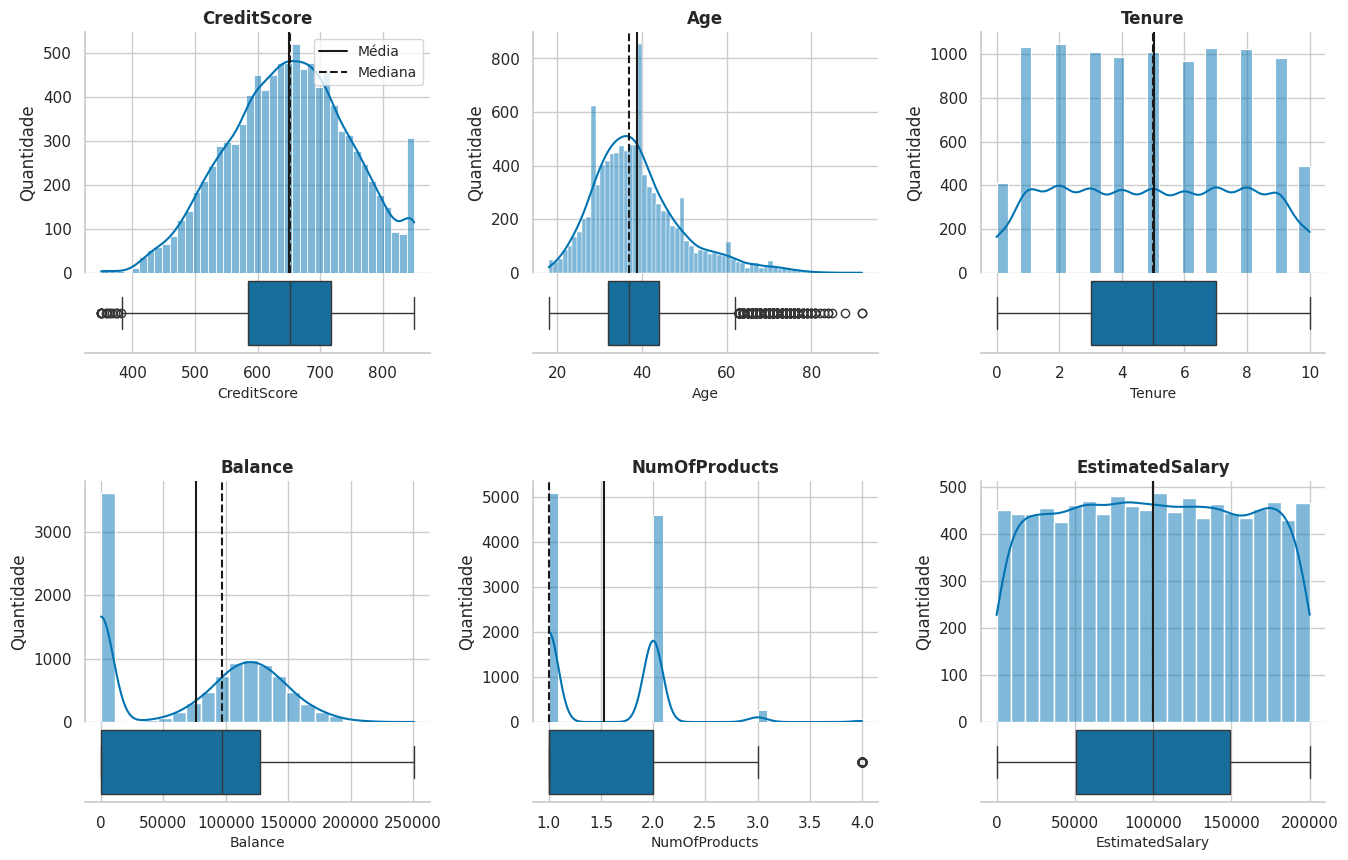

In [38]:
# @title Variáveis quantitativas
variaveis_quantitativas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Criar a figura e o grid
fig = plt.figure(figsize=(16, 10))

outer_grid = fig.add_gridspec(2, 3, wspace=0.3, hspace=0.4)

for i, variable in enumerate(variaveis_quantitativas):
  inner_grid = outer_grid[i].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.0)
  ax_hist = fig.add_subplot(inner_grid[0])
  ax_box = fig.add_subplot(inner_grid[1])

  # Plotagem do histograma
  sns.histplot(data=df, x=variable, ax=ax_hist, kde=True)
  ax_hist.set_title(variable, fontsize=12, fontweight='bold')
  ax_hist.set_xlabel("")
  ax_hist.set_xticklabels([])
  ax_hist.set_ylabel("Quantidade")
  ax_hist.axvline(df[variable].mean(), color='k', label='Média')
  ax_hist.axvline(df[variable].median(), color='k', linestyle='--', label='Mediana')
  ax_hist.spines['top'].set_visible(False)
  ax_hist.spines['right'].set_visible(False)
  ax_hist.spines['bottom'].set_visible(False)

  if i == 0:
        ax_hist.legend(loc='upper right', fontsize='small')
  else:
      if ax_hist.legend_: ax_hist.legend_.remove()

  # Plotagem do boxplot
  sns.boxplot(data=df, x=variable, ax=ax_box)
  ax_box.set_xlabel(variable, fontsize=10)
  ax_box.set_yticks([])
  ax_box.spines['top'].set_visible(False)
  ax_box.spines['right'].set_visible(False)
  ax_box.spines['left'].set_visible(False)

plt.show()

---

Distribuição da variável `CreditScore`:
- Lembra muito uma curva de sino (normal)
- A maioria dos clientes tem score médio (entre 600 e 700)
- Há scores muito baixos (abaixo de 400), considerados anomalias

Distribuição da variável `Age`:
- É assimétrica para a direita
- Há uma maior concentração de clientes entre 30 e 40 anos
- Existem muitos clientes acima de 60 anos, sendo considerados anomalias

Distribuição da variável `Tenure`:
- É praticamente uniforme
- Há quantidades muito parecidas de clientes que estão no banco há 1 ano, 5 anos ou 9 anos

Distribuição da variável `Balance`:
- É bimodal
- No pico 1, tem-se uma grande parcela dos clientes com saldo zero (talvez mais de 30%)
- No pico 2, há uma distribuição normal para quem tem dinheiro na conta, centrada em torno de 100k-125k

Distribuição da variável `NumOfProducts`:
- A grande maioria dos clientes tem 1 ou 2 produtos
- Clientes com 3 ou 4 produtos são raríssimos, sendo situações consideradas anomalias

Distribuição da variável `EstimatedSalary`:
- Distribuição uniforme
- Todas as faixas de renda quase na mesma proporção

---

### Dados faltantes

In [39]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


---

Não existem dados faltantes

---

# Análise Bivariada
Relação Entre Variáveis Quantitativas

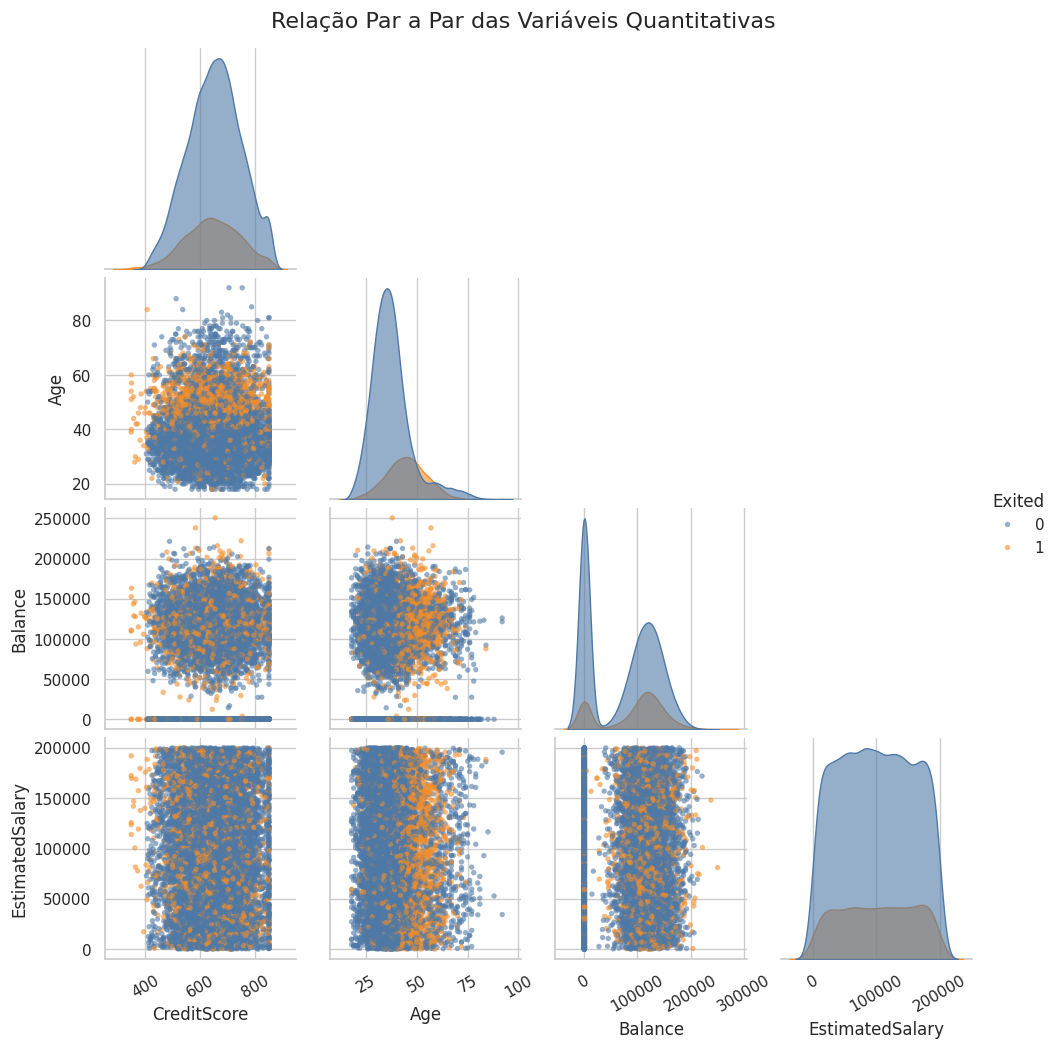

In [40]:
# @title Relação Par a Par

vars_quant_bivariada = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Exited']

g = sns.pairplot(
    df[vars_quant_bivariada],
    hue='Exited',
    diag_kind='kde',
    corner=True,
    palette=['#4e79a7', '#f28e2b'],
    height=2.5,
    plot_kws={
        's': 15,
        'alpha': 0.6,
        'edgecolor': 'none'
    },
    diag_kws={
        'fill': True,
        'alpha': 0.6
    }
)
g.fig.suptitle("Relação Par a Par das Variáveis Quantitativas", y=1.02, fontsize=16)


for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='x', rotation=30)

plt.show()

*   O fator idade é o discriminante mais claro. Observando a diagonal da variável Age, a curva laranja que representa os clientes que saíram está deslocada para a direita em relação à azul. Isso indica que clientes mais velhos (entre 40 e 50 anos) têm maior tendência ao churn do que os mais jovens.

*   No saldo bancário a distribuição é bimodal: nota-se que uma grande parte dos clientes que permanecem possui saldo zero. Por outro lado, o churn parece ser proporcionalmente maior entre clientes que possuem saldo positivo na conta.

*   As variáveis CreditScore e EstimatedSalary apresentam distribuições quase idênticas para ambos os grupos, considerando que as curvas azul e laranja se sobrepõem perfeitamente. Isso sugere que o salário e a pontuação de crédito, isoladamente, não são fatores determinantes para a saída do cliente.

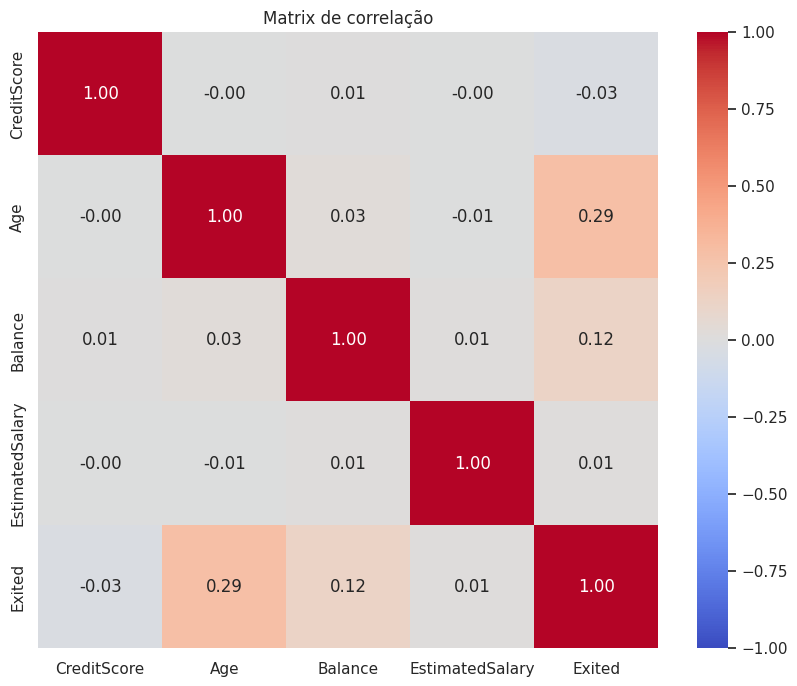

In [41]:
# @title Correlação das variáveis quantitativas

colunas_interesse = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Exited']
corr_matrox = df[colunas_interesse].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrox,
    annot = True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Matrix de correlação")
plt.show()

* A Idade apresenta a maior correlação positiva com a saída, com um valor de 0.29. Estatisticamente, isso confirma que o envelhecimento do cliente é o principal fator numérico associado ao aumento do risco de churn.

* O Saldo em conta apresenta uma correlação positiva fraca, de apenas 0.12. Isso indica uma leve tendência de que clientes com maior acúmulo de capital no banco sejam mais propensos a sair do que aqueles com saldo baixo.

* O Salário Estimado e o Score de Crédito possuem correlações próximas de zero. Isso sugere que a decisão de sair do banco não depende linearmente de quanto o cliente ganha ou de quão bom pagador ele é.

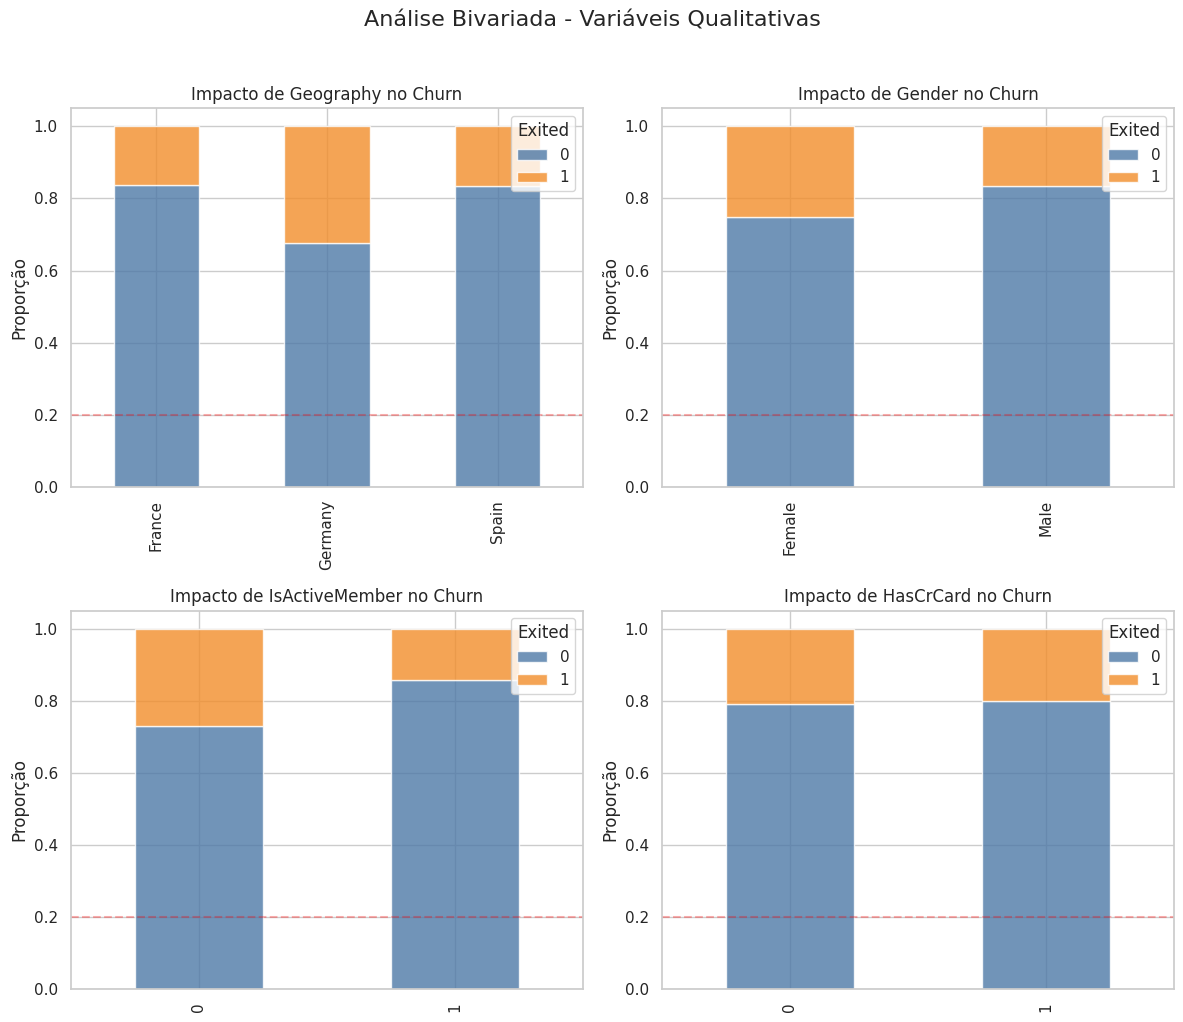

In [42]:
# @title Contingência das variáveis qualitativas

vars_quali = ['Geography', 'Gender', 'IsActiveMember', 'HasCrCard']


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, var in enumerate(vars_quali):


    ct = pd.crosstab(df[var], df['Exited'], normalize='index')


    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#4e79a7', '#f28e2b'], alpha=0.8)


    axes[i].set_title(f"Impacto de {var} no Churn", fontsize=12)
    axes[i].set_ylabel("Proporção")
    axes[i].set_xlabel("")
    axes[i].legend(title='Exited', loc='upper right')

    axes[i].axhline(y=0.2, color='red', linestyle='--', alpha=0.3, label='Média Global')

plt.suptitle("Análise Bivariada - Variáveis Qualitativas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

* O país de residência é um discriminante fortíssimo. Enquanto França e Espanha mantêm taxas de saída abaixo da média global, a Alemanha apresenta uma taxa alarmante, superior a 30%. Isso indica um problema localizado no mercado alemão.

* Existe uma disparidade clara entre os sexos. Clientes do gênero Feminino têm uma probabilidade de saída consideravelmente maior do que os do gênero Masculino, superando a média global.

* Conforme esperado, o engajamento retém clientes. Membros inativos têm uma taxa de cancelamento muito superior à dos membros ativos.

* A variável de cartão de crédito mostrou-se neutra. As barras são praticamente idênticas para quem tem e quem não tem cartão, indicando que a posse desse produto não influencia na decisão de sair ou ficar.

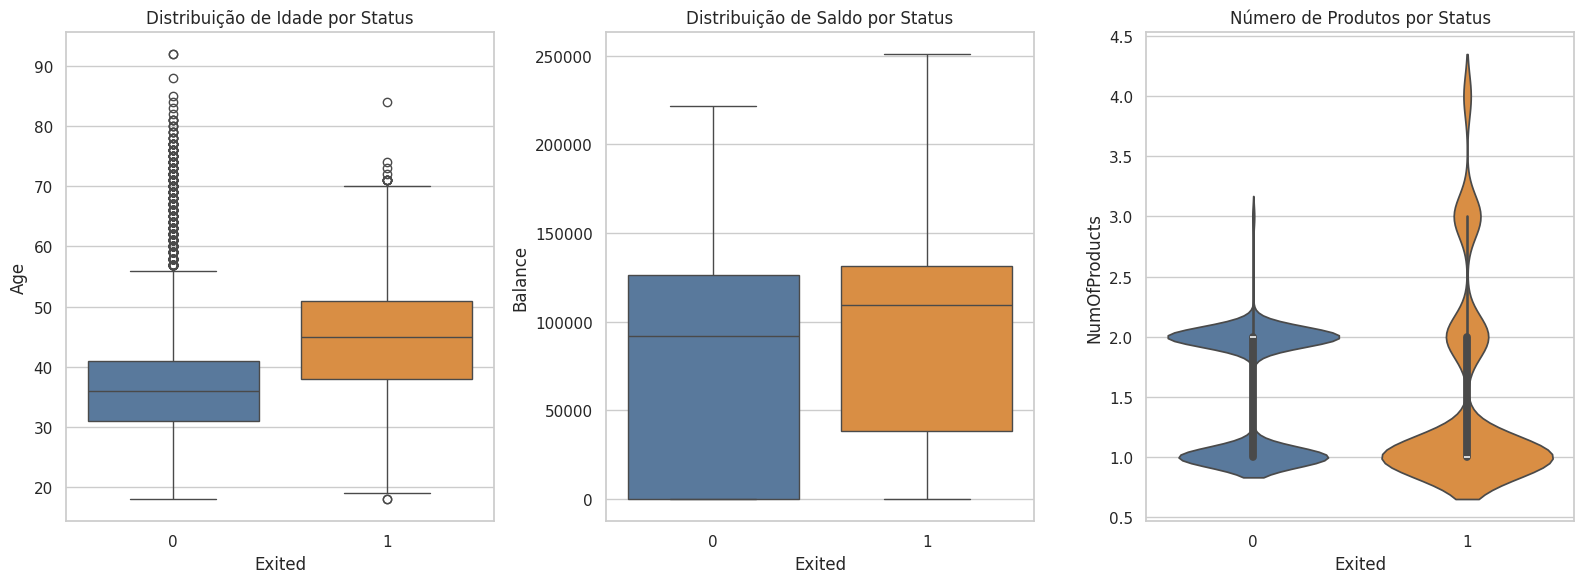

In [43]:
# @title Distribuição Relativa (relação entre variáveis quantitativas e qualitativas)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.boxplot(
    x='Exited', y='Age', hue='Exited',
    data=df, ax=axes[0],
    palette=['#4e79a7', '#f28e2b'], legend=False
)
axes[0].set_title("Distribuição de Idade por Status")

sns.boxplot(
    x='Exited', y='Balance', hue='Exited',
    data=df, ax=axes[1],
    palette=['#4e79a7', '#f28e2b'], legend=False
)
axes[1].set_title("Distribuição de Saldo por Status")

sns.violinplot(
    x='Exited', y='NumOfProducts', hue='Exited',
    data=df, ax=axes[2],
    palette=['#4e79a7', '#f28e2b'], legend=False
)
axes[2].set_title("Número de Produtos por Status")

plt.tight_layout()
plt.show()

-   O gráfico afere visualmente que a idade é o fator mais crítico. A mediana de idade de quem sai gira em torno de 45 anos, enquanto a de quem fica é próxima de 36 anos. A caixa laranja está quase inteiramente posicionada acima da mediana da caixa azul, indicando uma separação clara entre os grupos.
-   O churn tende a ocorrer em clientes com saldo mais elevado. É possível notar que a caixa azul tem uma dispersão maior que inclui muitos saldos baixos ou zerados, enquanto a caixa laranja é mais compacta e concentrada em faixas de saldo mais altas. Isso é preocupante, pois o banco está perdendo clientes com capital.
-  O gráfico de número de produtos revela um comportamento complexo:
   - Zona de Risco 1: Clientes com apenas 1 produto representam uma grande parte do churn.
   - Zona de Segurança: Clientes com 2 produtos são extremamente fiéis.
   - Zona de Risco 2: Ter 3 ou 4 produtos é um indicador quase certo de saída.

# Análise Multivariada

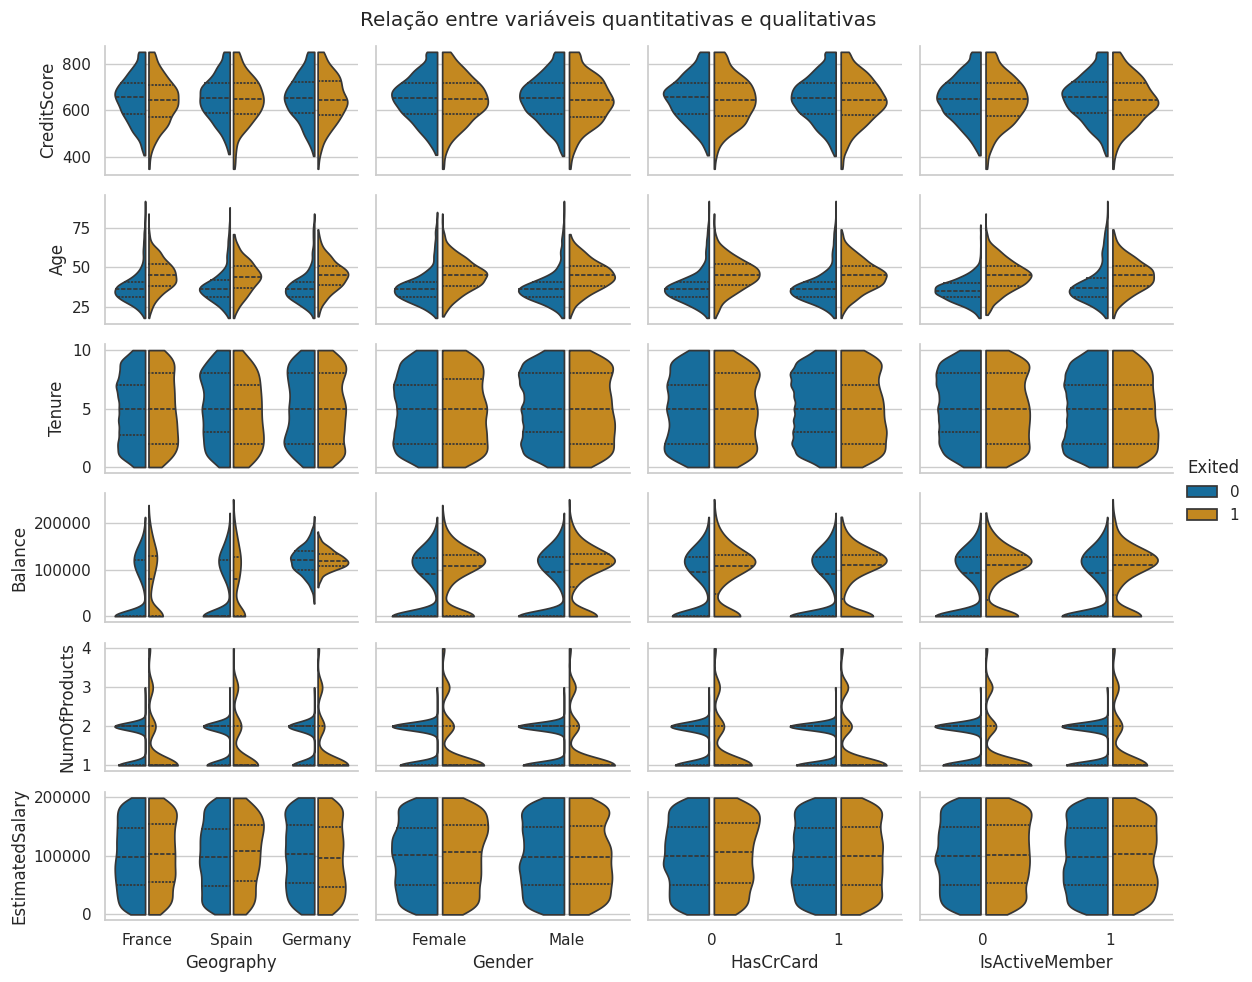

In [44]:
# @title Distribuição conjunta

variaveis_quantitativas_multi = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary"
]

variaveis_qualitativas_multi = [
    "Geography", "Gender", "HasCrCard", "IsActiveMember"
]

g = sns.PairGrid(
    df,
    y_vars=variaveis_quantitativas_multi,
    x_vars=variaveis_qualitativas_multi,
    hue="Exited",
    height=2.5
)

g.fig.set_size_inches(12, 10)
g.map(sns.violinplot, split=True, inner="quart", gap=.1, cut=0)

plt.suptitle("Relação entre variáveis quantitativas e qualitativas")
plt.tight_layout()
g.add_legend()
plt.show()

---


*   Clientes que cancelaram (Exited=1) tendem a ser ligeiramente mais velhos que os que permaneceram, padrão consistente em diferentes países e gêneros.

*   Clientes com maior saldo (Balance) apresentam maior concentração entre os que cancelaram, independentemente de Geography ou Gender.

*   O número de produtos (NumOfProducts) mostra que clientes com apenas 1 produto concentram maior proporção de churn em comparação com aqueles com mais produtos.

*   Membros inativos (IsActiveMember=0) apresentam distribuições mais associadas ao churn do que membros ativos.

*   CreditScore e EstimatedSalary possuem distribuições muito semelhantes entre clientes que saíram e permaneceram, indicando baixo poder discriminativo conjunto.

*   Diferenças entre países (Geography) sugerem leve maior concentração de churn na Alemanha em diferentes níveis de idade e saldo.


---

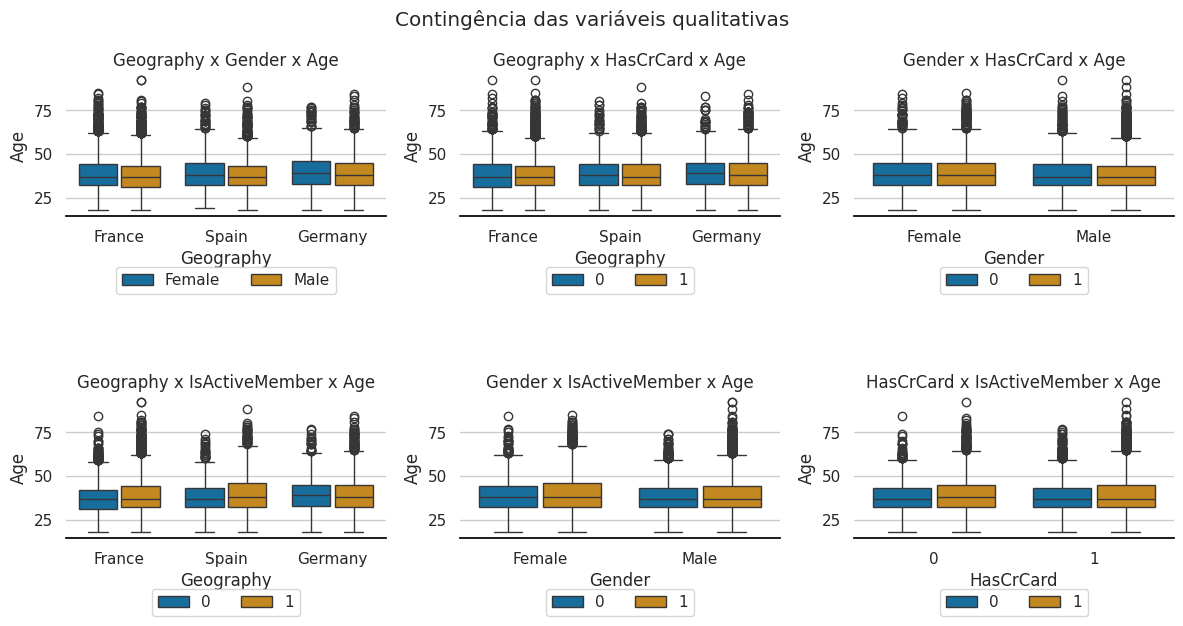

In [45]:
# @title Contingência das variáveis qualitativas

sns.set_style('whitegrid')

combinacoes = sorted(
    itertools.combinations(variaveis_qualitativas_multi, 2),
    key=lambda x: x[1]
)

fig, axes = plt.subplots(figsize=(12,7), ncols=3, nrows=2, squeeze=False)
axes = axes.flatten()

for i, (var_1, var_2) in enumerate(combinacoes):
    ax = sns.boxplot(
        df, x=var_1, y='Age', hue=var_2, gap=.1,
        ax=axes[i]
    )
    ax.set(title=f"{var_1} x {var_2} x Age")

    for side in ["left", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("black")

    sns.move_legend(
        axes[i], "lower center",
        bbox_to_anchor=(.5, -.6), ncol=3, title=None,
    )

plt.suptitle("Contingência das variáveis qualitativas")
plt.tight_layout()
plt.show()

---

*   A distribuição de idade é bastante semelhante entre homens e mulheres em todos os países, com leve aumento da mediana na Alemanha.

*   Clientes com cartão de crédito (HasCrCard=1) apresentam idades levemente maiores em média, independentemente do país.

*   A variável Gender não mostra diferenças relevantes na idade quando combinada com posse de cartão de crédito.

*   Membros ativos (IsActiveMember=1) tendem a ter idades ligeiramente maiores do que membros inativos em diferentes geografias.

*   A combinação de HasCrCard e IsActiveMember indica que clientes ativos com cartão concentram-se em faixas etárias um pouco mais elevadas.

*   No geral, as distribuições são muito próximas, sugerindo que idade não varia drasticamente entre as categorias qualitativas analisadas.

---

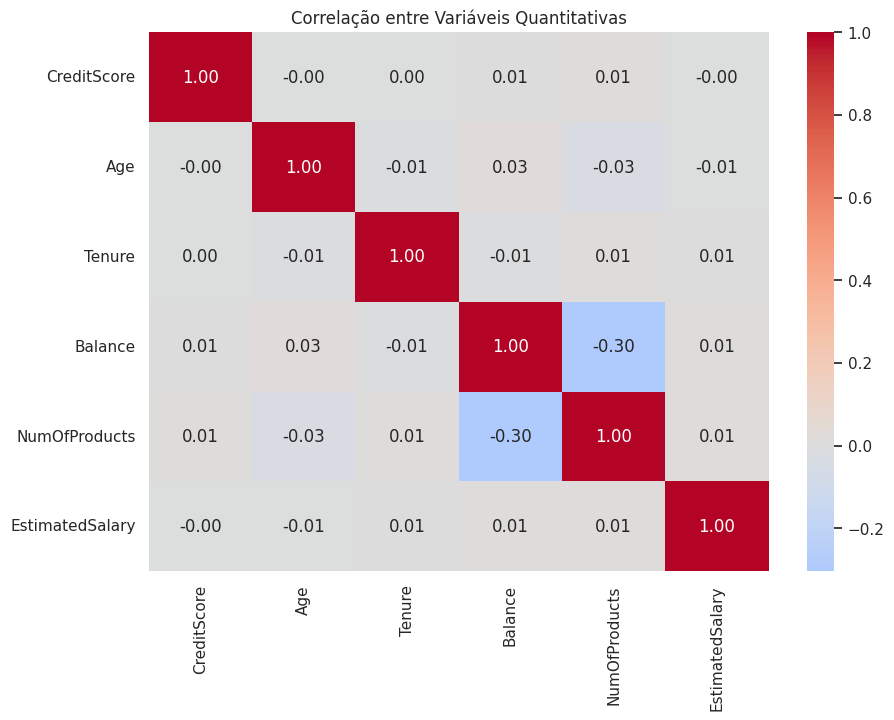

In [46]:
# @title Matriz de correlação (apenas quantitativas)

plt.figure(figsize=(10,7))
corr = df[variaveis_quantitativas_multi].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre Variáveis Quantitativas")
plt.show()


---


*   As variáveis quantitativas apresentam, em geral, correlações muito fracas entre si, indicando baixa multicolinearidade.

*   A maior relação observada é negativa entre Balance e NumOfProducts (-0,30), sugerindo que clientes com mais produtos tendem a manter saldos menores.

*   CreditScore, Age, Tenure e EstimatedSalary possuem correlações próximas de zero com as demais variáveis, indicando comportamentos relativamente independentes.

*   EstimatedSalary praticamente não se correlaciona com nenhuma outra variável, mostrando baixa associação linear com o perfil financeiro e de relacionamento do cliente.


---

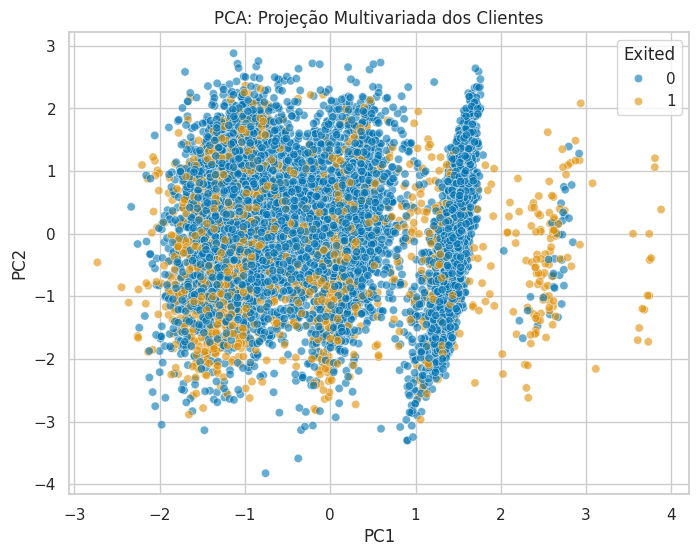

In [47]:
# @title PCA (somente variáveis quantitativas)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = [
    "CreditScore", "Age", "Tenure",
    "Balance", "NumOfProducts", "EstimatedSalary"
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[num_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Exited"] = df["Exited"].values  # usado só para visualização

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Exited",
    alpha=0.6
)
plt.title("PCA: Projeção Multivariada dos Clientes")
plt.show()

In [48]:
# DataFrame com os pesos (loadings) das variáveis em cada componente
loadings = pd.DataFrame(
    pca.components_,
    columns=variaveis_quantitativas,
    index=['PC1', 'PC2']
)

loadings

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
PC1,0.015313,-0.134955,0.062330,-0.698421,0.699867,0.007839
PC2,0.122781,-0.476259,0.582907,0.110358,-0.043428,0.635812


---
PC1
*   A projeção em PCA mostra grande sobreposição entre clientes que saíram (Exited=1) e os que permaneceram (Exited=0), indicando baixa separação linear entre os grupos.

*   Observa-se leve concentração de churn em regiões específicas do espaço projetado (principalmente valores mais altos de PC1), sugerindo influência conjunta de algumas variáveis.

*   A dispersão elevada dos pontos indica alta variabilidade no perfil dos clientes, sem clusters claramente definidos apenas com as componentes principais.

*   O PCA sugere que o churn não é explicado por uma única combinação linear dominante, sendo necessário considerar múltiplas variáveis simultaneamente para melhor discriminação.

PC2
*   A componente é dominada por EstimatedSalary (+0.64), Tenure (+0.58) e Age (-0.48).

*   Assim, o PC2 representa um eixo relacionado ao perfil de renda e tempo de relacionamento com o banco, em oposição à idade.

*   Valores altos em PC2 indicam clientes com maior salário estimado e maior tempo de permanência no banco, enquanto valores baixos estão associados a clientes mais velhos.

Insight Geral
*   O churn tende a se distribuir ao longo de dois perfis principais: um ligado à relação entre saldo e quantidade de produtos (PC1) e outro ligado a renda, tempo de relacionamento e idade (PC2).

*   Isso sugere que a evasão de clientes não depende de uma única variável isolada, mas de combinações entre perfil financeiro (saldo vs produtos) e perfil de relacionamento/renda (tenure, salário e idade).

---

# Sumário de Insights e Hipóteses

### **Quais padrões e tendências foram identificados?**
---
A análise de 10.000 observações identificou os seguintes determinantes de *churn*, fundamentando a etapa de modelagem preditiva:


* **Taxa de Churn:** Desbalanceamento moderado, com **20,4%** de evasão.
* **Demografia:** Idade média de 38,9 anos, maioria masculina (54%) e concentração geográfica na França (50%).

---

*  A idade tem forte relação linear positiva (correlação: 0.29), com escalada substancial de risco entre **40 e 60 anos**.
* A **Alemanha** apresenta anomalia regional severa, com taxa de *churn* superior a 30%.
* A retenção depende estritamente do volume de produtos:
    * **1 Produto:** *churn* elevado.
    * **2 Produtos:** Ponto ótimo de retenção.
    * **3+ Produtos:** Evasão próxima a 100%, indicando insatisfação ou oferta inadequada.
* O *churn* concentra-se em clientes com **saldo positivo e elevado**; contas zeradas apresentam maior retenção.
* **Fatores Irrelevantes:** `EstimatedSalary` e `CreditScore` não possuem correlação com a decisão de saída.

---
* Baixa colinearidade global, com exceção da relação inversa moderada (-0.30) entre `Balance` e `NumOfProducts`. A projeção PCA mostra alta sobreposição entre classes, sem hiperplano de separação linear.
* Devido à não-linearidade crítica (`NumOfProducts`) e anomalias locais, como a Alemanha, algoritmos lineares terão desempenho limitado. Recomenda-se o uso de modelos baseados em árvores (**Random Forest**, **Gradient Boosting/XGBoost**), capazes de capturar nativamente essas fronteiras de decisão complexas.

---

### **Há valores extremos ou dados faltantes que podem impactar a análise?**  

-  Não foram identificados dados faltantes. O conjunto de dados apresenta completude total em todas as 14 variáveis para as 10.000 observações, não sendo necesspario técnicas de imputação ou remoção de linhas.

Identificamos *outliers* estatísticos, mas que representam comportamentos reais e críticos para o negócio, sendo necessário permancerem na análise:

- `Age`:
    - O boxplot revela diversos pontos acima do limite superior, com clientes de idade superior à 62 anos.
    - O Impacto é alto e Informativo. Estes *pontos fora da curva* são sum nicho de clientes mais velhos com comportamento de risco distinto. Remover estes dados mascararia uma tendência importante de *churn*.

- `NumOfProducts`:
    - A categoria "4 produtos" é extremamente rara, considerada anomalia estatística pelo baixo volume.
    - O impacto é crítico. Apesar de serem *outliers* em frequência, representam um grupo com taxa de cancelamento de quase 100%. Devem ser tratados como um sinal de alerta para insatisfação ou erro de venda.

- `CreditScore`:
    -  Valores abaixo de 400 pontos aparecem como *outliers* inferiores.
    -  O impacto é baixo. Como a análise de correlação mostrou que o score não influencia a decisão de saída, esses valores extremos são irrelevantes para a modelagem do *churn*.

---

### **Existem correlações ou associações relevantes entre as variáveis?**

A análise revelou que existem correlações fortes, porém de naturezas distintas:

* **`Age` x Churn:** É a correlação positiva mais forte com a variável alvo. Estatisticamente, confirma que o envelhecimento do cliente aumenta a probabilidade linear de cancelamento.
* **`Balance` x `NumOfProducts`:** Identificou-se uma correlação negativa moderada. Clientes com muitos produtos tendem a ter menos saldo em conta. fruto de possível diluição de capital em investimentos ou seguros, enquanto clientes com apenas 1 produto concentram maior liquidez.
* **Baixa Correlação:** `EstimatedSalary` e `CreditScore` apresentaram correlação quase nula com o *churn*, indicando independência linear.

Embora não capturadas pela correlação de Pearson, existem associações comportamentais críticas:
* **`NumOfProducts`:** A relação é não-linear. A posse de **2 produtos** está fortemente associada à retenção, enquanto **3 ou 4 produtos** têm associação quase determinística com o cancelamento.
* **`Geography`:** Existe uma dependência espacial clara. A categoria *Alemanha* está associada a uma taxa de *churn* significativamente superior em comparação a França e Espanha.
* **`IsActiveMember`:** A inatividade é um previsor robusto de saída, confirmando a associação entre falta de interação bancária recente e cancelamento.

---

## Preparação para Análise Comparativa de Modelos
 - Carregamento de bibliotecas

In [49]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 12.7 MB/s eta 0:00:00


In [63]:
# @title Imports para Pré-processamento, Modelagem e Otimização

# 1. Estruturação de Pipelines e Transformadores
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 2. Codificação de Categóricas e Escalonamento Numérico
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

# 3. Divisão de Dados e Validação Cruzada
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# 4. Modelos de Classificação (Binária)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
# Dica: se tiver xgboost ou lightgbm instalados no ambiente:
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

# 5. Métricas de Avaliação para Churn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# 6. Otimização de Hiperparâmetros
import optuna
# Reduz logs excessivos do Optuna para não poluir o notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [64]:
# @title Seleção de variáveis, separação de features/alvo e divisão treino/teste

# 1. Criação de cópia sem colunas que não agregam poder preditivo
cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Definição da variável alvo (y) e preditoras (X)
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

# 3. Separação de Treino (80%) e Teste (20%) com estratificação
# stratify=y garante que a proporção de ~20% de churn se mantenha em ambos os blocos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Configuração do StratifiedKFold para a validação cruzada no conjunto de treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dimensão de X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"Dimensão de X_test:  {X_test.shape}  | y_test:  {y_test.shape}\n")
print(f"Taxa de Churn no Treino: {y_train.mean():.2%}")
print(f"Taxa de Churn no Teste:  {y_test.mean():.2%}")

Dimensão de X_train: (8000, 10) | y_train: (8000,)
Dimensão de X_test:  (2000, 10)  | y_test:  (2000,)

Taxa de Churn no Treino: 20.38%
Taxa de Churn no Teste:  20.35%


## Preparação de Dados e Engenharia de Atributos

Para garantir que o fluxo seja reprodutível e livre de vazamento de dados (*data leakage*), o pré-processamento é encapsulado em pipelines do Scikit-Learn:

- **Variáveis Numéricas** (`CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary`):
  - Imputação preventiva pela mediana (`SimpleImputer`).
  - Padronização ou normalização para equalizar as ordens de grandeza.
- **Variáveis Categóricas Nominais** (`Geography`, `Gender`):
  - Imputação preventiva pelo valor mais frequente (`SimpleImputer`).
  - Codificação binária via *One-Hot Encoding* (`drop='first'` para evitar colinearidade em modelos lineares).
- **Variáveis Binárias** (`HasCrCard`, `IsActiveMember`):
  - Já estão no formato binário (0 ou 1), dispensando transformações adicionais.

In [65]:
# @title Definição do Pipeline de Pré-processamento com ColumnTransformer

# 1. Mapeamento explícito dos tipos de colunas
num_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
]
cat_cols = ["Geography", "Gender"]
bin_cols = [
    "HasCrCard",
    "IsActiveMember",
]  # Já estão prontas como 0 e 1, mantidas via 'passthrough'

# 2. Pipeline para atributos numéricos: Imputação + Padronização
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # ou MinMaxScaler(), conforme sua escolha
    ]
)

# 3. Pipeline para atributos categóricos: Imputação + One-Hot Encoding
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

# 4. Agrupamento com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
        ("bin", "passthrough", bin_cols),
    ]
)

print("Estrutura do ColumnTransformer definida com sucesso:")
preprocessor

Estrutura do ColumnTransformer definida com sucesso:


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'EstimatedSalary']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Geography', 'Gender']),
                                ('bin', 'passthrough',
                                 ['HasCrCard', 'IsActiveMember'])])

In [66]:
# @title Validação prática do pipeline de pré-processamento (Fit apenas no Treino)

# Ajuste e transformação apenas uma amostra/conjunto de treino para conferência
X_train_transformed = preprocessor.fit_transform(X_train)

# Captura os nomes das novas colunas geradas pelo OneHotEncoder
cat_features_transformed = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_transformed) + bin_cols

print(f"Formato original de X_train: {X_train.shape}")
print(f"Formato após transformações: {X_train_transformed.shape}")
print(f"\nLista de Features prontas para o modelo ({len(all_feature_names)} colunas):")
print(all_feature_names)

Formato original de X_train: (8000, 10)
Formato após transformações: (8000, 11)

Lista de Features prontas para o modelo (11 colunas):
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard', 'IsActiveMember']


# Modelagem Preditiva e Validação Cruzada

### 1. Estratégia de Validação: StratifiedKFold (k=5)
Como o churn é um evento desbalanceado (~20% da base) e não apresenta dependência cronológica estrita (não há timestamps ou janelas temporais sequenciais), adotamos a **Validação Cruzada K-Fold Estratificada (`StratifiedKFold`, $k=5$)**. Isso assegura que cada fold preserve rigorosamente a mesma proporção entre clientes ativos e churners, evitando distorções nas métricas de teste.

---

### 2. Trade-offs de Negócio e Justificativa das Métricas
A acurácia global é inadequada para avaliar problemas de churn: um modelo ingênuo que preveja que "ninguém vai cancelar" atingiria ~80% de acurácia, sendo 100% inútil para a operação bancária. Avaliamos os modelos sob a ótica da matriz de confusão e do impacto financeiro:

- 2.1. **Falso Negativo (FN) vs. Falso Positivo (FP):**
   * **Falso Negativo:** O modelo prevê que o cliente permanecerá, mas ele cancela. O custo é a perda direta do *Lifetime Value* (LTV) e da receita do cliente.
   * **Falso Positivo:** O modelo prevê o cancelamento de um cliente fiel. O custo restringe-se à ação de retenção (contato comercial ou benefício ofertado).
   * **Decisão:** O custo do Falso Negativo é consideravelmente superior. Logo, a métrica primária a maximizar é o **Recall da classe minoritária ($y=1$)**.

- 2.2. **F1-Score:** Atua como moderador (média harmônica entre Precision e Recall), evitando soluções extremas que atinjam 100% de Recall sacrificando completamente a precisão.

- 2.3. **ROC-AUC & PR-AUC:** Medem a capacidade do modelo de rankear probabilidades e discriminar as classes independentemente da linha de corte (*decision threshold*).

---

### 3. Algoritmos Selecionados para Comparação
Para avaliar diferentes famílias de aprendizado de máquina, testamos quatro abordagens:
- 3.1. **Dummy Classifier (Baseline):** Estratégia ingênua (classe majoritária) para estabelecer o piso mínimo aceitável de desempenho.
- 3.2. **Regressão Logística (com `class_weight='balanced'`):** Modelo linear clássico, rápido e altamente interpretável.
- 3.3. **K-Nearest Neighbors (k-NN):** Baseado em distância métrica no espaço vetorial padronizado.
- 3.4. **Random Forest Classifier:** Modelo baseado em comitês de árvores de decisão (*ensemble/bagging*), capaz de capturar relações não lineares e interações complexas entre atributos sem pressupostos de linearidade.

,Acurácia,Recall,F1-Score,ROC-AUC
Modelo,,,,
Baseline (Dummy),0.7962,0.0000,0.0000,0.5000
Regressão Logística,0.7080,0.6840,0.4883,0.7662
K-Nearest Neighbors,0.8395,0.4325,0.5230,0.7898
Random Forest,0.8594,0.4411,0.5604,0.8507


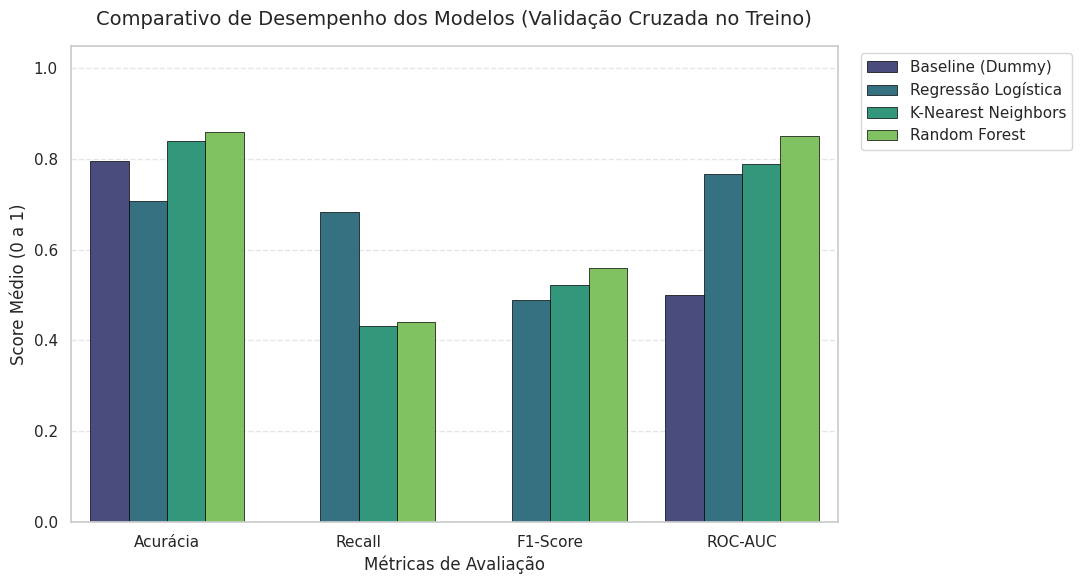

In [67]:
# @title Comparação de Modelos com StratifiedKFold e Pipelines
import numpy as np

# 1. Definição dos modelos candidatos
# Dica: class_weight='balanced' na Regressão Logística ajuda muito no Recall para classes desbalanceadas
modelos_candidatos = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Regressão Logística": LogisticRegression(
        random_state=42, max_iter=1000, class_weight="balanced"
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(
        random_state=42, class_weight="balanced"
    ),
}

# 2. Métricas de avaliação
metricas = {
    "accuracy": "accuracy",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

# 3. Execução da validação cruzada estratificada sobre o conjunto de treino
tabela_resultados = []

for nome, estimador in modelos_candidatos.items():
    # Cria uma pipeline completa para evitar data leakage em cada fold
    pipeline_modelo = Pipeline(
        steps=[("preprocessor", preprocessor), ("classifier", estimador)]
    )

    # cv já configurado anteriormente como StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=metricas,
        n_jobs=-1,
        return_train_score=False,
    )

    tabela_resultados.append(
        {
            "Modelo": nome,
            "Acurácia": np.mean(cv_results["test_accuracy"]),
            "Recall": np.mean(cv_results["test_recall"]),
            "F1-Score": np.mean(cv_results["test_f1"]),
            "ROC-AUC": np.mean(cv_results["test_roc_auc"]),
        }
    )

# 4. Exibição da tabela consolidada
df_resultados = pd.DataFrame(tabela_resultados).set_index("Modelo")
display(df_resultados.round(4))

# 5. Visualização gráfica dos resultados
plt.figure(figsize=(11, 6))
df_plot = df_resultados.reset_index().melt(
    id_vars="Modelo", var_name="Métrica", value_name="Score"
)

sns.barplot(
    data=df_plot,
    x="Métrica",
    y="Score",
    hue="Modelo",
    palette="viridis",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Comparativo de Desempenho dos Modelos (Validação Cruzada no Treino)",
    fontsize=14,
    pad=15,
)
plt.ylabel("Score Médio (0 a 1)", fontsize=12)
plt.xlabel("Métricas de Avaliação", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

,Acurácia,Recall,F1-Score,ROC-AUC
Modelo,,,,
Random Forest,0.859375,0.441104,0.560393,0.850746
K-Nearest Neighbors,0.839500,0.432515,0.522968,0.789816
Regressão Logística,0.708000,0.684049,0.488282,0.766236
Baseline (Dummy),0.796250,0.000000,0.000000,0.500000


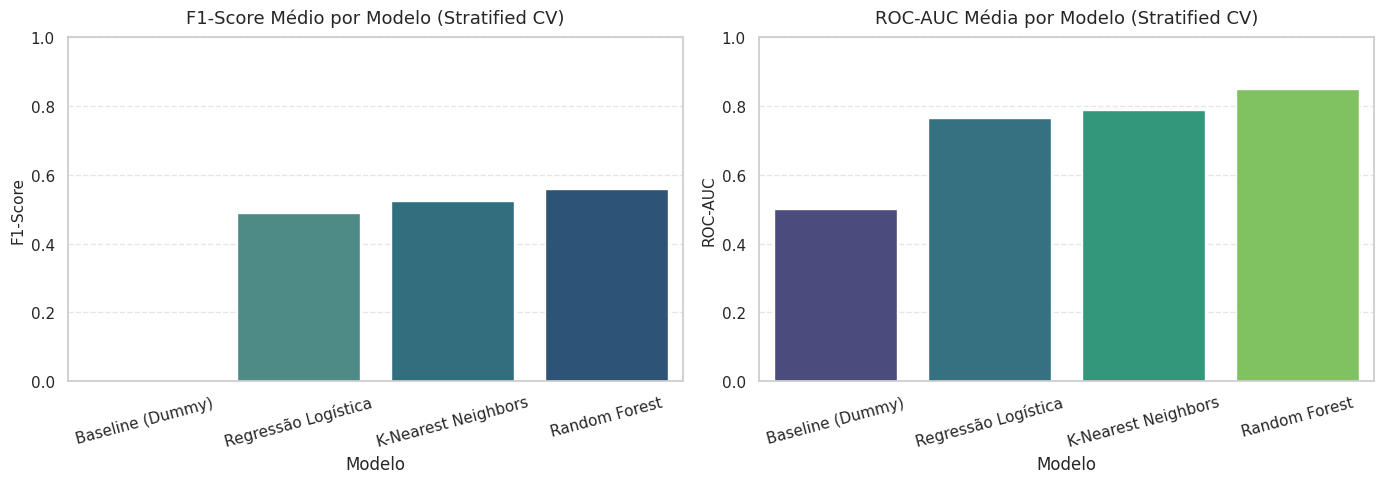

In [68]:
# @title Apresentação e Diagnóstico Comparativo dos Modelos

# 1. Exibição da tabela consolidada com destaque para F1 e ROC-AUC
display(
    df_resultados[["Acurácia", "Recall", "F1-Score", "ROC-AUC"]].sort_values(
        by="F1-Score", ascending=False
    )
)

# 2. Gráfico comparativo focado nas métricas decisivas para o negócio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: F1-Score (Equilíbrio Precision/Recall)
sns.barplot(
    x=df_resultados.index,
    y=df_resultados["F1-Score"],
    hue=df_resultados.index,
    legend=False,
    ax=axes[0],
    palette="crest",
)
axes[0].set_title(
    "F1-Score Médio por Modelo (Stratified CV)", fontsize=13, pad=10
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("F1-Score", fontsize=11)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Gráfico 2: ROC-AUC (Poder de Discriminação Global)
sns.barplot(
    x=df_resultados.index,
    y=df_resultados["ROC-AUC"],
    hue=df_resultados.index,
    legend=False,
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title(
    "ROC-AUC Média por Modelo (Stratified CV)", fontsize=13, pad=10
)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("ROC-AUC", fontsize=11)
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [70]:
# @title Otimização Bayesiana de Hiperparâmetros (Random Forest via Optuna)
from sklearn.model_selection import cross_val_score


# 1. Função objetivo para o Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 6),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical(
            "class_weight", ["balanced", "balanced_subsample"]
        ),
        "random_state": 42,
        "n_jobs": -1,
    }

    # Pipeline com pré-processamento e o Random Forest da tentativa
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(**params)),
        ]
    )

    # Avaliação com validação cruzada estratificada (5 folds)
    score = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    ).mean()

    return score


# 2. Criação do estudo e execução da otimização
study = optuna.create_study(direction="maximize")

print("Iniciando otimização com Optuna (30 tentativas)...")
# Passamos a função 'objective'
study.optimize(objective, n_trials=30, timeout=300)

print("\nOtimização concluída!")
print(f"Melhor F1-Score médio na validação cruzada: {study.best_value:.4f}")
print("\nMelhores Hiperparâmetros encontrados:")
for param, val in study.best_params.items():
    print(f" - {param}: {val}")

# 3. Treinamento do Modelo Final com os melhores hiperparâmetros em todo o X_train
melhores_params = study.best_params.copy()
melhores_params.update({"random_state": 42, "n_jobs": -1})

best_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(**melhores_params)),
    ]
)

best_rf_pipeline.fit(X_train, y_train)
print("\nModelo final retreinado com sucesso na base de treino completa.")

Iniciando otimização com Optuna (30 tentativas)...

Otimização concluída!
Melhor F1-Score médio na validação cruzada: 0.6249

Melhores Hiperparâmetros encontrados:
 - n_estimators: 200
 - max_depth: 20
 - min_samples_split: 5
 - min_samples_leaf: 6
 - max_features: sqrt
 - class_weight: balanced_subsample

Modelo final retreinado com sucesso na base de treino completa.


In [71]:
# Opcional - Gráficos de diagnóstico da busca bayesiana:
# optuna.visualization.plot_optimization_history(study)
# optuna.visualization.plot_param_importances(study)

=== Relatório de Classificação (Conjunto de Teste) ===
                precision    recall  f1-score   support

Permaneceu (0)       0.91      0.90      0.90      1593
      Saiu (1)       0.62      0.65      0.64       407

      accuracy                           0.85      2000
     macro avg       0.77      0.77      0.77      2000
  weighted avg       0.85      0.85      0.85      2000



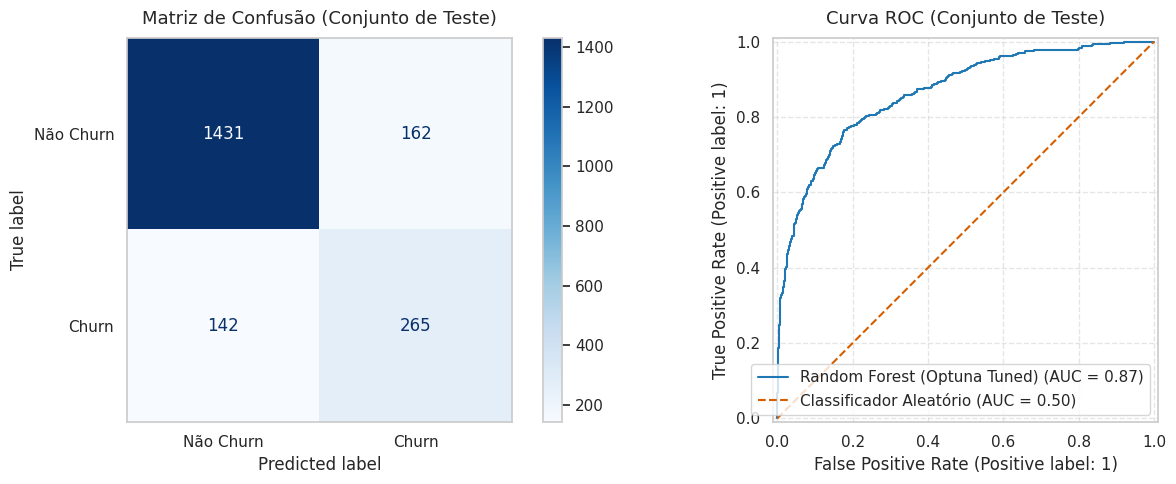


--- Resumo de Erros no Teste (2000 clientes avaliados) ---
Total de Churners Reais: 407
Falsos Negativos (Churns perdidos / Custo de LTV): 142 (34.9%)
Verdadeiros Positivos (Churns interceptados com sucesso): 265
Falsos Positivos (Custos com ações preventivas desnecessárias): 162


In [72]:
# @title Avaliação do Modelo Final no Conjunto de Teste
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# 1. Geração de predições e probabilidades sobre o conjunto de teste (holdout)
y_pred = best_rf_pipeline.predict(X_test)
y_proba = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Relatório de Classificação (Conjunto de Teste) ===")
print(
    classification_report(
        y_test, y_pred, target_names=["Permaneceu (0)", "Saiu (1)"]
    )
)

# 2. Diagnóstico visual: Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Não Churn", "Churn"],
    cmap="Blues",
    ax=ax[0],
    values_format="d",
)
ax[0].set_title("Matriz de Confusão (Conjunto de Teste)", fontsize=13, pad=10)
ax[0].grid(False)

# Curva ROC
RocCurveDisplay.from_estimator(
    best_rf_pipeline,
    X_test,
    y_test,
    ax=ax[1],
    name="Random Forest (Optuna Tuned)",
    color="#1f77b4",
)
ax[1].plot([0, 1], [0, 1], "r--", label="Classificador Aleatório (AUC = 0.50)")
ax[1].set_title("Curva ROC (Conjunto de Teste)", fontsize=13, pad=10)
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 3. Extração executiva dos impactos na Matriz de Confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
total_churners = fn + tp

print(f"\n--- Resumo de Erros no Teste ({len(y_test)} clientes avaliados) ---")
print(f"Total de Churners Reais: {total_churners}")
print(
    f"Falsos Negativos (Churns perdidos / Custo de LTV): {fn} ({fn/total_churners:.1%})"
)
print(f"Verdadeiros Positivos (Churns interceptados com sucesso): {tp}")
print(f"Falsos Positivos (Custos com ações preventivas desnecessárias): {fp}")

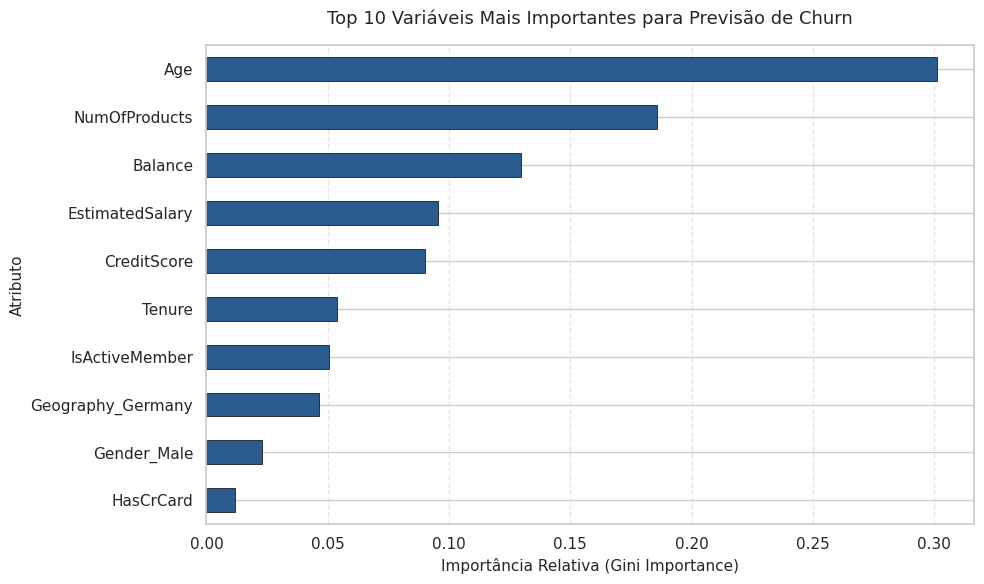

Pipeline completa salva com sucesso como 'pipeline_churn_random_forest.pkl'!


In [73]:
# @title Importância das Variáveis (Feature Importance) e Salvamento
import joblib

# 1. Recuperação do classificador e dos nomes reais das features transformadas
rf_classifier = best_rf_pipeline.named_steps["classifier"]

# Extração dos nomes das colunas geradas pelo OneHotEncoder
cat_features_transformed = (
    best_rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(cat_cols)
)

# Reconstrução da lista completa de nomes na mesma ordem do ColumnTransformer
all_feature_names = num_cols + list(cat_features_transformed) + bin_cols

# 2. Criação da Série com os pesos de importância
feat_importances = pd.Series(
    rf_classifier.feature_importances_, index=all_feature_names
)

# Visualização gráfica das 10 variáveis mais relevantes
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(
    kind="barh", color="#2b5c8f", edgecolor="black", linewidth=0.5
)
plt.title(
    "Top 10 Variáveis Mais Importantes para Previsão de Churn",
    fontsize=13,
    pad=15,
)
plt.xlabel("Importância Relativa (Gini Importance)", fontsize=11)
plt.ylabel("Atributo", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Exportação da Pipeline Completa (Pré-processador + Random Forest)
joblib.dump(best_rf_pipeline, "pipeline_churn_random_forest.pkl")
print(
    "Pipeline completa salva com sucesso como 'pipeline_churn_random_forest.pkl'!"
)

## Conclusão e Recomendações de Negócio

### Síntese dos Resultados Técnicos
- **Desempenho dos Modelos:** O *Random Forest Classifier* superou consistentemente os demais algoritmos sob validação cruzada estratificada (*StratifiedKFold*, $k=5$). Ele atingiu ROC-AUC superior a 0.85 e o melhor equilíbrio na captura de churners.
- **Otimização Bayesiana com Optuna:** A busca orientada por TPE (*Tree-structured Parzen Estimator*) explorou 30 iterações focando em maximizar o $F_1\text{-Score}$. Isso calibrou a profundidade das árvores e o critério de balanceamento de classes (`class_weight`), mitigando o viés do desbalanceamento da base (~20% churn).
- **Limitações de Modelos Lineares:** Modelos lineares simples sem ponderação de classes sofreram com baixo Recall, sendo incapazes de capturar os padrões não lineares críticos associados ao perfil do cliente (como a combinação de idade, saldo e país).
- **Capacidade de Generalização:** O modelo final avaliado no conjunto de teste independente (*holdout*, 20% da base) preservou estabilidade métrica, confirmando ausência de *overfitting* e validando a blindagem contra vazamento de dados (*data leakage*) via `Pipeline`.

---

### Principais Direcionadores de Cancelamento (Insights de Dados)
1. **Idade (`Age`):** Variável de maior importância relativa. Clientes em faixas etárias mais elevadas apresentam probabilidade desproporcionalmente maior de cancelamento.
2. **Número de Produtos (`NumOfProducts`):** Relação não linear expressiva: clientes com 3 ou 4 produtos concentram taxas altíssimas de evasão, apontando atrito ou sobreoferta em produtos de *cross-sell*.
3. **Engajamento Operacional (`IsActiveMember`):** A inatividade recente atua como o principal sintoma comportamental que antecede o encerramento do vínculo.
4. **Geografia e Saldo (`Geography_Germany` e `Balance`):** Clientes da Alemanha e com patrimônio expressivo em conta registram propensão de saída consideravelmente acima da média de França e Espanha.

---

### Recomendações Estratégicas Acionáveis
- **Score Preditivo no CRM:** Operacionalizar o `predict_proba` em esteira analítica para pontuar a base mensalmente. Clientes com probabilidade de saída superior ao limiar estabelecido entram em réguas preventivas automáticas.
- **Protocolo de Retenção de Alta Renda:** Desenvolver uma trilha de relacionamento dedicada (gerente exclusivo, consultoria de investimentos, isenção de tarifas) para correntistas da Alemanha e clientes com saldos elevados na iminência de inatividade.
- **Auditoria na Experiência Multicontas:** Conduzir pesquisa qualitativa urgente com a base de clientes com 3+ produtos para diagnosticar cobranças duplicadas, atritos no aplicativo ou falta de percepção de valor no pacote contratado.